# 01 — Data Exploration

This notebook inspects the **MDCC GoFundMe corpus** (Xu, Li & Zhou, 2023, CIKM) and
the auxiliary descriptive Kaggle Kickstarter file.

By the end of this notebook you will know:

1. How many campaigns MDCC contains, what columns are present.
2. The category distribution and the text-length distribution.
3. What the weak-label distribution looks like (binary and four-class).
4. Why the original Kaggle Kickstarter CSVs are unsuitable as the primary text source.

We reuse `src.preprocessing.load_mdcc` so the cleaning pipeline matches the one
the models will see.


In [1]:
# Path-setup boilerplate so the notebook can import src.*
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("project root:", ROOT)


project root: /Users/spandarayamajhi/Desktop/Artificial Intelligence Coursework (Final Submission)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.preprocessing import load_mdcc

sns.set_theme(style="whitegrid")


## 1. Load MDCC (primary corpus)

In [3]:
df = load_mdcc()
print(f"rows: {len(df):,}")
print(f"columns: {list(df.columns)}")
df.head(3)


rows: 14,961
columns: ['campaign_id', 'category', 'text', 'goal', 'raised']


,campaign_id,category,text,goal,raised
0,10yr-old-kalicia-to-fight-cancer,Medical,10-year-old Kalicia is the firstborn of the Fr...,100000.0,12500.0
1,1230-miles-and-48-hours-chasing-a-cure,Medical,Hello! My name is Amy Rossiter Crist. I have a...,10000.0,11392.0
2,123456-for-katie,Medical,"Katie Stembridge is a beloved sister, daughter...",7000.0,7000.0


## 2. Category distribution

category
Memorial               4632
Medical                3580
Animals                2879
Emergency              2526
Financial Emergency    1344
Name: count, dtype: int64


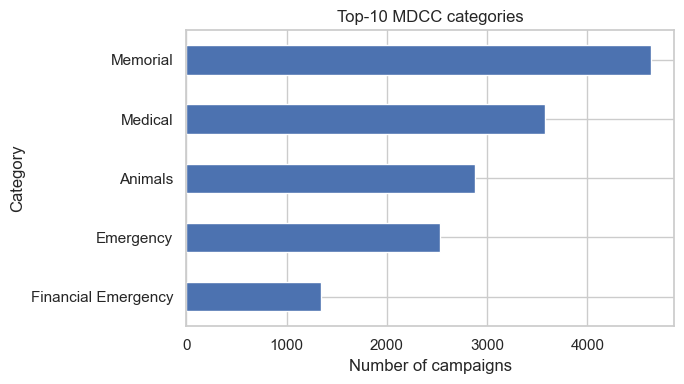

In [4]:
cat_counts = df['category'].value_counts()
print(cat_counts.head(10))
fig, ax = plt.subplots(figsize=(7,4))
cat_counts.head(10).plot.barh(ax=ax)
ax.set_xlabel('Number of campaigns'); ax.set_ylabel('Category')
ax.set_title('Top-10 MDCC categories')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()


The corpus is dominated by **Memorial**, **Medical**, **Animals**, **Emergency**
and **Financial Emergency** — i.e. donation categories where emotional appeals
are most plausible. This matches the manipulation registers we target in the
research question.


## 3. Text-length distribution

count    14961.0
mean      1210.0
std       1084.0
min         25.0
25%        570.0
50%        915.0
75%       1484.0
max      21741.0
Name: text, dtype: float64


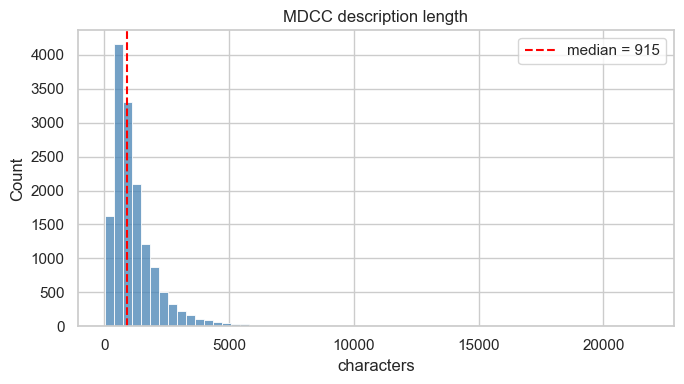

In [5]:
lengths = df['text'].str.len()
print(lengths.describe().round(0))
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(lengths, bins=60, ax=ax, color='steelblue')
ax.axvline(lengths.median(), color='red', linestyle='--',
           label=f'median = {int(lengths.median())}')
ax.set_xlabel('characters'); ax.set_title('MDCC description length')
ax.legend(); plt.tight_layout(); plt.show()


Critical takeaway: the **maximum length exceeds 21,000 characters** while the
median is ~900. Any transformer fine-tune must include a `max_length` cap
(we use 192 tokens for CPU-tractable training; the project spec allows up to 512).


## 4. Weak-label distribution

In [6]:
labelled = pd.read_csv(config.WEAK_LABELS_CSV)
print('binary:')
print(labelled['binary_label'].value_counts())
print('\nfine-grained:')
print(labelled['fine_label'].value_counts())


binary:
binary_label
non_manipulative    8545
manipulative        6416
Name: count, dtype: int64

fine-grained:
fine_label
non_manipulative         8545
guilt_or_fear            2727
sympathy_exploitation    2047
artificial_urgency       1642
Name: count, dtype: int64


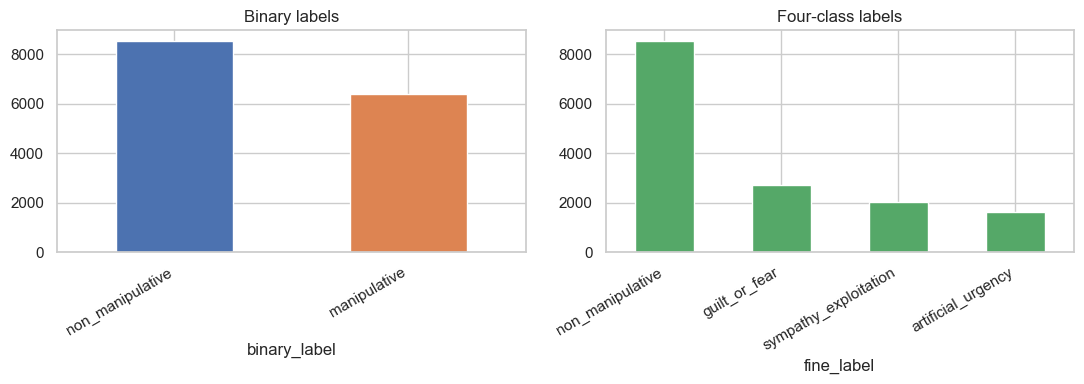

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
labelled['binary_label'].value_counts().plot.bar(ax=axes[0], color=['#4c72b0','#dd8452'])
axes[0].set_title('Binary labels')
labelled['fine_label'].value_counts().plot.bar(ax=axes[1], color='#55a868')
axes[1].set_title('Four-class labels')
for ax in axes:
    for tick in ax.get_xticklabels(): tick.set_rotation(30); tick.set_ha('right')
plt.tight_layout(); plt.show()


The keyword heuristic flags roughly 43 % of campaigns as manipulative — moderately
balanced. The fine-grained breakdown skews toward **guilt_or_fear** (negative-affect
language) which matches the dominance of Memorial / Medical categories.


## 5. Why the original Kaggle CSVs are unusable as text input

In [8]:
import pandas as pd
ks = pd.read_csv(config.KAGGLE_KS, low_memory=False, nrows=5)
ks


,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,canceled,14,US,1283.0,1283.0,19500.00


The Kaggle `ks-projects-201801.csv` is **metadata only** — no campaign description
text. It is retained in this project only for descriptive context (success rates
by category, country, goal range) in the report's Introduction, not as model
input.
